**Purpose:** Main thesis results: performance comparison across all strategies and feature sets.

**Inputs:** `03_portfolio/dataset.parquet`

**Outputs:** `thesis/figs/reddit_token_distribution.png`, `thesis/figs/model_performance_radar.png`

**Notes:** paths resolve via `src.config` (run `pip install -e .` from the repo root first).


In [ ]:
from src.config import PROJECT_ROOT


*The results indicate that different sentiment data sources contribute to performance through fundamentally different mechanisms. Reddit sentiment behaves as a relatively direct, short-horizon predictive signal, closely linked to behavioural trading activity and temporary price pressure, which allows both predictive models and reinforcement learning approaches to extract substantial improvements in Sharpe ratio. In contrast, news sentiment appears to contain more contextual and regime-related information, influencing factors such as volatility, persistence of trends, and optimal exposure rather than simply forecasting next-period returns. Consequently, sequential decision frameworks like deep reinforcement learning are better positioned to exploit this information through dynamic portfolio adjustments, while traditional predictive architectures capture only part of its economic value. Together, these findings highlight that the effectiveness of alternative data depends not only on its informational content but also on the alignment between signal structure and model design.*

---

In [1]:
import os
import numpy as np
import pandas as pd

from src.metrics import PortfolioMetrics
pm = PortfolioMetrics()

DATASET = pd.read_parquet(str(PROJECT_ROOT / "03_portfolio/dataset.parquet"))

ASSETS = ['XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']

# i should map files to names, use assert to validate all files are mapped

In [2]:
weights_files = [file for file in os.listdir() if file.endswith(".npy")]

assert weights_files == [file for file in weights_files if file.split("_")[-1] == "weights.npy"]

approaches = {}
for file in weights_files:
    approach_name = file.split("_")[0]
    approach_type = file.split("_")[1]
    if approach_name not in approaches:
        approaches[approach_name] = []
    approaches[approach_name].append(approach_type)

for approach_name, approach_types in approaches.items():
    print(f"Approach: '{approach_name}': {sorted(approach_types)}")

print(f"\nMissing approaches (here): {'SP500'} and {'1 asset aka ETF (curiosity)'}")

Approach: 'LSTMvia-sharpe': ['news', 'reddit', 'reddit+news', 'technical']
Approach: 'LSTMvia-returns': ['news', 'reddit', 'reddit+news', 'technical']
Approach: 'MVOCAPM': ['benchmark']
Approach: 'EW': ['benchmark']
Approach: 'DRLPPO': ['news', 'reddit', 'reddit+news', 'technical']

Missing approaches (here): SP500 and 1 asset aka ETF (curiosity)


In [3]:
results_summary = {}
for weights_file in weights_files:
    weights = np.load(weights_file)
    approach_name = "_".join(weights_file.split("_")[:-1])
    
    metrics = pm.summary(weights)
    results_summary[approach_name] = metrics

results_summary["SP500"] = {'cumulative_return': np.float64(0.3942518074190029), 'volatility': np.float64(0.161071580651578), 'sharpe_ratio': np.float64(0.8034739421156498), 'max_drawdown': np.float64(-0.18902206184283987)}

pd.DataFrame(results_summary).T.sort_values(by="sharpe_ratio", ascending=False)

,cumulative_return,volatility,sharpe_ratio,max_drawdown
DRLPPO_reddit+news,0.596331,0.161668,1.222867,-0.130472
LSTMvia-sharpe_reddit,0.854797,0.238170,1.211834,-0.256588
DRLPPO_reddit,0.537735,0.151211,1.172636,-0.146560
LSTMvia-returns_reddit,0.481202,0.133973,1.164157,-0.097153
LSTMvia-sharpe_reddit+news,0.580164,0.181235,1.081219,-0.160805
DRLPPO_news,0.423845,0.140377,0.975536,-0.116139
LSTMvia-returns_reddit+news,0.415878,0.138375,0.966852,-0.116655
LSTMvia-sharpe_news,0.446935,0.163650,0.906533,-0.149382
MVOCAPM_benchmark,0.379678,0.146057,0.834660,-0.187855
LSTMvia-sharpe_technical,0.471065,0.196568,0.828903,-0.238277


In [4]:
# DATASET["_REDDIT_NAN"].value_counts()
# DATASET["_NEWS_NAN"][-500:].values 

---

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt

import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

# Match your thesis: Latin Modern via LaTeX rendering
mpl.rcParams.update({
    # Use LaTeX for all text rendering
    "text.usetex": True,
    "font.family": "serif",

    # Latin Modern — matches your \usepackage{lmodern}
    "font.serif": ["Latin Modern Roman"],
    "font.sans-serif": ["Latin Modern Sans"],   # matches \sffamily in headings
    "font.monospace": ["Latin Modern Mono"],    # matches your TTT font

    # Match your thesis font size (11pt base)
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    # Load lmodern in the LaTeX preamble — critical for matching
    "pgf.preamble": "\n".join([
        r"\usepackage[utf8]{inputenc}",
        r"\usepackage[T1]{fontenc}",
        r"\usepackage{lmodern}",
    ]),

    # Line spacing loosely mirrors your \linespread{1.5}
    "figure.dpi": 600,
})


# plt.figure(figsize=(5.71*1.5, 3.5))

# # ...

# plt.tight_layout()
# # plt.savefig(str(PROJECT_ROOT / "thesis/figs/reddit_token_distribution.png"), bbox_inches="tight")
# plt.show()

In [6]:
WEIGHTS_files = {
    "LSTMvreturns": {
        "Technical": "weights/LSTMvia-returns_technical_weights.npy",
        "Technical+Reddit": "weights/LSTMvia-returns_reddit_weights.npy",
        "Technical+News": "weights/LSTMvia-returns_news_weights.npy",
        "Technical+Reddit+News": "weights/LSTMvia-returns_reddit+news_weights.npy",
    },
    "LSTMvsharpe": {
        "Technical": "weights/LSTMvia-sharpe_technical_weights.npy",
        "Technical+Reddit": "weights/LSTMvia-sharpe_reddit_weights.npy",
        "Technical+News": "weights/LSTMvia-sharpe_news_weights.npy",
        "Technical+Reddit+News": "weights/LSTMvia-sharpe_reddit+news_weights.npy",
    },
    "DRLPPO": {
        "Technical": "weights/DRLPPO_technical_weights.npy",
        "Technical+Reddit": "weights/DRLPPO_reddit_weights.npy",
        "Technical+News": "weights/DRLPPO_news_weights.npy",
        "Technical+Reddit+News": "weights/DRLPPO_reddit+news_weights.npy",
    },
    "MVO-CAPM": {
        "Benchmark": "weights/MVOCAPM_benchmark_weights.npy",
    },
    "EW": {
        "Benchmark": "weights/EW_benchmark_weights.npy",
    },
}

In [7]:
# for approach_name, variants in WEIGHTS_files.items():
#     print(f"Approach: '{approach_name}':")
#     for variant_name, weights_file in variants.items():
#         weights = np.load(weights_file)

#         print(f"  Variant: '{variant_name}'")
#         print(pm.summary(weights))

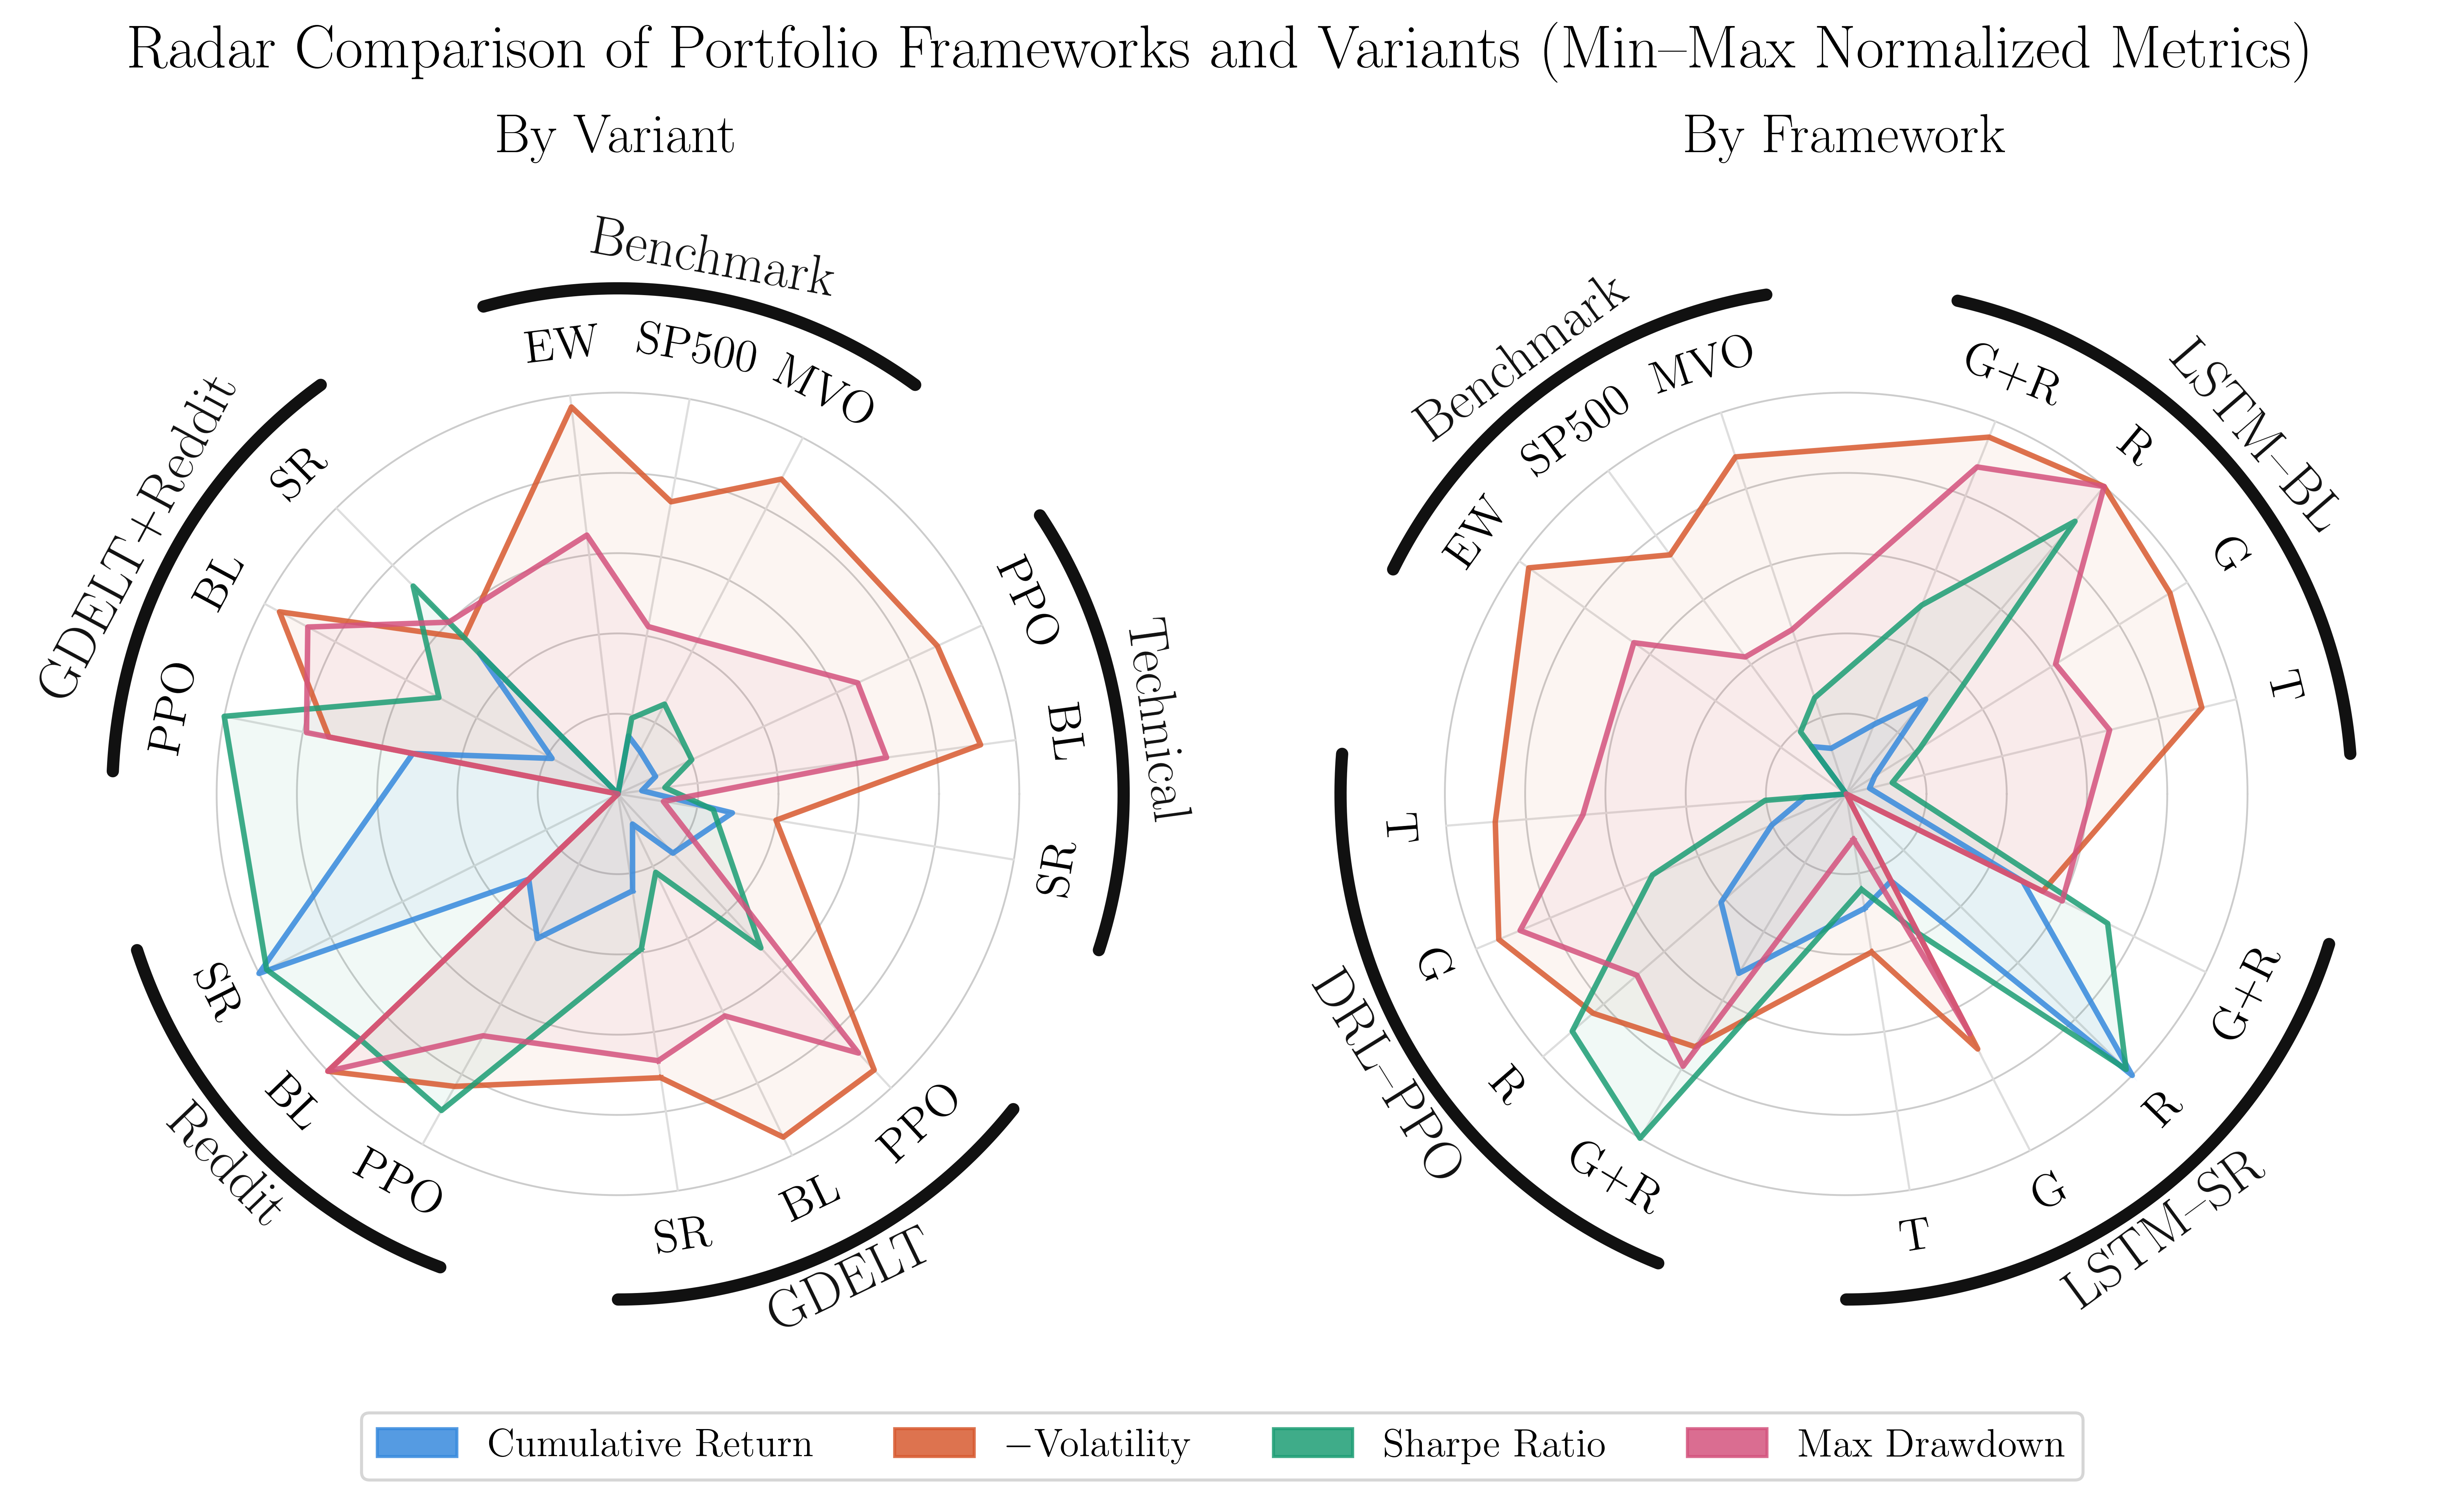

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ══════════════════════════════════════════════════════════════════════════════
# 0. SHARED CONFIG
# ══════════════════════════════════════════════════════════════════════════════
metrics       = ["cumulative_return", "volatility", "sharpe_ratio", "max_drawdown"]
metric_labels = ["Cumulative Return", "$-$Volatility", "Sharpe Ratio", "Max Drawdown"]
metric_colors = ["#378ADD", "#D85A30", "#1D9E75", "#D4537E"]

GAP_SLOTS = 1.2
START_OFF = -np.pi / 2

OUTER_MODELS = {"DRLPPO", "LSTMvia-sharpe", "LSTMvia-returns"}

# ══════════════════════════════════════════════════════════════════════════════
# 1. BUILD BASE DATAFRAME
# ══════════════════════════════════════════════════════════════════════════════
df_raw = pd.DataFrame(results_summary).T \
           .sort_values(by="sharpe_ratio", ascending=False) \
           .reset_index() \
           .rename(columns={"index": "model"})

df_raw.loc[df_raw["model"] == "SP500", "model"] = "SP500_benchmark"
df_raw[["base_model", "variant"]] = df_raw["model"].str.split("_", n=1, expand=True)

df_raw["volatility"] = df_raw["volatility"] * -1  # Invert volatility so higher is better for ranking and visualization

# ══════════════════════════════════════════════════════════════════════════════
# 2. HELPERS
# ══════════════════════════════════════════════════════════════════════════════
def normalize_metrics(df):
    df = df.copy()
    for m in metrics:
        col = df[m]
        min_val = col.min()
        max_val = col.max()
        denom = max_val - min_val
        if denom == 0:
            df[f"{m}_norm"] = 0.5  # all models tied on this metric
        else:
            df[f"{m}_norm"] = (col - min_val) / denom
    return df
# def rank_metrics(df):
#     df = df.copy()
#     for m in metrics:
#         df[f"{m}_rank"] = df[m].rank()
#     return df

def compute_angles(df, group_col, group_order):
    n_points    = len(df)
    n_groups    = len(group_order)
    total_slots = n_points + GAP_SLOTS * n_groups

    angles     = np.full(n_points, np.nan)
    group_meta = {}
    slot_cursor = 0.0

    for g in group_order:
        mask = df[group_col] == g
        size = mask.sum()
        if size == 0:
            continue
        idx = df.index[mask].tolist()
        for k, i in enumerate(idx):
            slot = slot_cursor + k + 0.5
            angles[i] = START_OFF + (slot / total_slots) * 2 * np.pi

        a0 = START_OFF + (slot_cursor          / total_slots) * 2 * np.pi
        a1 = START_OFF + ((slot_cursor + size)  / total_slots) * 2 * np.pi
        group_meta[g] = (a0, a1, (a0 + a1) / 2)
        slot_cursor += size + GAP_SLOTS

    return angles, group_meta

def label_rotation(angle_rad):
    a   = angle_rad % (2 * np.pi)
    deg = np.degrees(a)
    rot = deg - 90
    if 180 < deg < 360:
        rot += 180
    return rot

def draw_radar(ax, df, angles, group_meta,
               spoke_label_col,
               outer_label_col,
               R, ARC_R, LABEL_R, VLABEL_R,
               outer_colors=None):

    # ── NO global angle sort here — df is already in clockwise group order
    # Just use as-is; angles[i] corresponds to df.iloc[i]

    # Grid rings
    for ring in np.linspace(R / 5, R, 5):
        ax.plot(np.linspace(0, 2 * np.pi, 360), [ring] * 360,
                color="#cccccc", lw=0.6, zorder=0)

    # Spoke lines
    for angle in angles:
        ax.plot([angle, angle], [0, R], color="#dedede", lw=0.7, zorder=0)

    # Metric polygons — drawn in the order spokes were assigned (clockwise by group)
    for m, color, label in zip(metrics, metric_colors, metric_labels):
        vals = df[f"{m}_norm"].tolist()
        a_loop = list(angles) + [angles[0]]
        v_loop = vals + [vals[0]]
        ax.plot(a_loop, v_loop, color=color, lw=1.8, alpha=0.85, label=label, zorder=3)
        ax.fill(a_loop, v_loop, color=color, alpha=0.06, zorder=2)

    # Per-spoke labels
    for angle, name in zip(angles, df[spoke_label_col]):
        rot = label_rotation(angle)
        ax.text(angle, LABEL_R, str(name),
                ha="center", va="center",
                fontsize=15, color="black",
                rotation=rot, rotation_mode="anchor", zorder=5)

    # Outer arc + group labels
    for g, (a0, a1, mid) in group_meta.items():
        color = (outer_colors or {}).get(g, "#111111")
        arc_a = np.linspace(a0, a1, 200)
        ax.plot(arc_a, [ARC_R] * 200,
                color=color, lw=4, solid_capstyle="round", zorder=6)
        rot = label_rotation(mid)
        ax.text(mid, VLABEL_R, str(g),
                ha="center", va="center",
                fontsize=18, fontweight="bold", color=color,
                rotation=rot, rotation_mode="anchor", zorder=7)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines["polar"].set_visible(False)
    ax.grid(False)
    ax.set_ylim(0, VLABEL_R * 1.1)

# ══════════════════════════════════════════════════════════════════════════════
# 3. PLOT 1  –  outer = variant, spokes = base_model
# ══════════════════════════════════════════════════════════════════════════════
def label_mapper(word):
    map = {"LSTMvia-sharpe": "SR", "LSTMvia-returns": "BL", "DRLPPO": "PPO", "MVOCAPM": "MVO", "SP500": "SP500", "EW": "EW",
           "technical": "Technical", "news": "GDELT", "reddit": "Reddit", "reddit+news": "GDELT+Reddit", "benchmark": "Benchmark"}
    
    return map.get(word, "CONA")

variant_order = ["GDELT", "Technical", "Benchmark", "GDELT+Reddit", "Reddit"]
model_order   = ["SR", "BL", "PPO", "MVO", "SP500", "EW"]

df1 = df_raw.copy()
df1["base_model"] = df1["base_model"].apply(label_mapper)
df1["variant"] = df1["variant"].apply(label_mapper)


df1["base_model"] = pd.Categorical(df1["base_model"], categories=model_order,  ordered=True)
df1["variant"]    = pd.Categorical(df1["variant"],    categories=variant_order, ordered=True)
df1 = df1.sort_values(["variant", "base_model"]).reset_index(drop=True)
df1 = normalize_metrics(df1)

R1 = df1[[f"{m}_norm" for m in metrics]].values.max()
angles1, group_meta1 = compute_angles(df1, "variant", variant_order)
angles1 = np.array(angles1)

# ══════════════════════════════════════════════════════════════════════════════
# 4. PLOT 2  –  outer = model, spokes = variant (technical > news > reddit > reddit+news)
# ══════════════════════════════════════════════════════════════════════════════
df2 = df_raw.copy()

def label_mapper(word):
    map = {"LSTMvia-sharpe": "LSTM--SR", "LSTMvia-returns": "LSTM--BL", "DRLPPO": "DRL--PPO", "MVOCAPM": "MVO", "SP500": "SP500", "EW": "EW",
           "technical": "T", "news": "G", "reddit": "R", "reddit+news": "G+R", "benchmark": "Benchmark"}
    
    return map.get(word, "CONA")

def map_outer_inner(row):
    if row['base_model'] in OUTER_MODELS:
        return pd.Series([row['base_model'], row['variant']])
    elif row['base_model'] in ["SP500", "EW", "MVOCAPM"]:
        return pd.Series(["benchmark", row['base_model']])
    else:
        return pd.Series([row['base_model'], row['variant']])

df2[['outer_group', 'spoke_label']] = df2.apply(map_outer_inner, axis=1)

outer_group_order = ["LSTM--SR", "LSTM--BL", "Benchmark", "DRL--PPO"]
spoke_order = ["T", "G", "R", "G+R", "MVO", "SP500", "EW"]

df2["base_model"] = df2["base_model"].apply(label_mapper)
df2["variant"] = df2["variant"].apply(label_mapper)
df2["spoke_label"] = df2["spoke_label"].apply(label_mapper)
df2["outer_group"] = df2["outer_group"].apply(label_mapper)

df2['outer_group'] = pd.Categorical(df2['outer_group'], categories=outer_group_order, ordered=True)
df2['spoke_label'] = pd.Categorical(df2['spoke_label'], categories=spoke_order,       ordered=True)

# Sort THEN rank so ranks reflect angular order
df2 = df2.sort_values(["outer_group", "spoke_label"]).reset_index(drop=True)
df2 = normalize_metrics(df2)

angles2, group_meta2 = compute_angles(df2, "outer_group", outer_group_order)
angles2 = np.array(angles2)
R2 = df2[[f"{m}_norm" for m in metrics]].values.max()

# ══════════════════════════════════════════════════════════════════════════════
# 5. DRAW
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(
    1, 2,
    figsize=(5.71 * 2 , 3.5*2),
    subplot_kw=dict(polar=True)
)

ARC_MULT    = 1.26
LABEL_MULT  = 1.12
VLABEL_MULT = 1.35



# ── Plot 1
ax1 = axes[0]
draw_radar(
    ax1, df1, angles1, group_meta1,
    spoke_label_col="base_model",
    outer_label_col="variant",
    R=R1,
    ARC_R   = R1 * ARC_MULT,
    LABEL_R = R1 * LABEL_MULT,
    VLABEL_R= R1 * VLABEL_MULT,
    outer_colors=None,
)
ax1.set_title("By Variant", fontsize=18, pad=15)

# ── Plot 2
ax2 = axes[1]
draw_radar(
    ax2, df2, angles2, group_meta2,
    spoke_label_col="spoke_label",
    outer_label_col="outer_group",
    R=R2,
    ARC_R   = R2 * ARC_MULT,
    LABEL_R = R2 * LABEL_MULT,
    VLABEL_R= R2 * VLABEL_MULT,
    outer_colors=None
)
ax2.set_title("By Framework", fontsize=18, pad=15)

# ── Shared legend
handles = [mpatches.Patch(color=c, label=l, alpha=0.85)
           for c, l in zip(metric_colors, metric_labels)]
fig.legend(handles=handles,
           loc="lower center",
           ncol=4,
           frameon=True,
           fontsize=13,
           bbox_to_anchor=(0.5, 0.01))

plt.suptitle(
    "Radar Comparison of Portfolio Frameworks and Variants (Min--Max Normalized Metrics)",
    fontsize=20,
    y=0.97
)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "thesis/figs/model_performance_radar.png"), bbox_inches="tight", dpi=900)
plt.show()